### House Price Prediction

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

#### Load the dataset

In [17]:
df = pd.read_csv(r"C:\Users\238w1a5412\Downloads\archive\data.csv") 
print(df.head())
print(df.describe())
print(df.isnull().sum())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [ ]:
df.fillna(df.mean(), inplace=True) 

#### One Hot Encoding

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
print(df.columns)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above',
       ...
       'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168',
       'statezip_WA 98177', 'statezip_WA 98178', 'statezip_WA 98188',
       'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288',
       'statezip_WA 98354'],
      dtype='object', length=4725)


In [22]:
X = df.drop(columns=['price']) 
y = df['price']

#### Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Train the model

In [26]:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)

LinearRegression()

In [27]:
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

In [28]:
y_pred_1 = model1.predict(X_test_scaled)
y_pred_2 = model2.predict(X_test_scaled)

#### Performance

In [30]:
print("Linear Regression Performance:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_1)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_1)}")
print(f"R-squared: {r2_score(y_test, y_pred_1)}")

Linear Regression Performance:
Mean Absolute Error: 262749.11623209174
Mean Squared Error: 1147215101578.438
R-squared: -0.12489014911856589


In [31]:
print("\nRandom Forest Performance:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_2)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_2)}")
print(f"R-squared: {r2_score(y_test, y_pred_2)}")


Random Forest Performance:
Mean Absolute Error: 156973.28543343415
Mean Squared Error: 970366186587.6766
R-squared: 0.04851726338995266


#### Visualisation

Text(0, 0.5, 'Predicted Values')

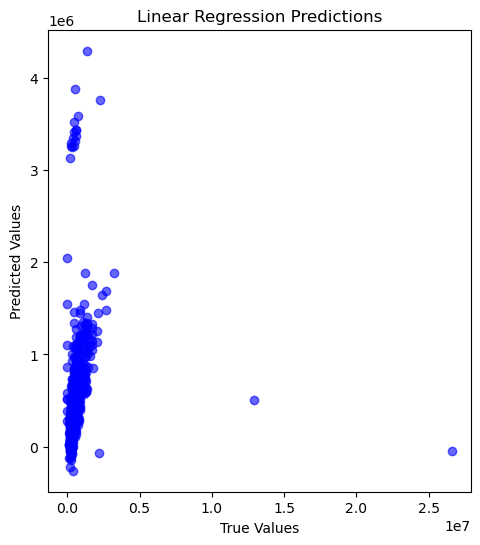

In [33]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_1, color='blue', alpha=0.6)
plt.title("Linear Regression Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")

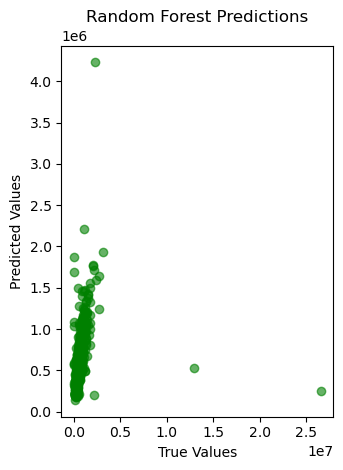

In [35]:
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_2, color='green', alpha=0.6)
plt.title("Random Forest Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.show()
